In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('bollywood.csv')

In [4]:
# viewing the first few rows of the dataset
# the head() function displays the first 5 rows of the dataframe
df.head()

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224


In [5]:
df.shape[0]

149

In [6]:

# 2. finding the number of movies by release time sorted in the descending order
df.ReleaseTime.value_counts()

,count
ReleaseTime,
N,99
HS,18
FS,17
LW,15


In [7]:

# formatting the genre column
df.Genre = df.Genre.str.strip()

# 3. finding the genre with the highest number of releases during the festive season
df[df.ReleaseTime=='FS'].Genre.value_counts()

,count
Genre,
Drama,4
Thriller,4
Action,3
Romance,3
Comedy,3


In [8]:

# 4. cross tab between Genre and ReleaseTime
pd.crosstab(df.Genre, df.ReleaseTime)


ReleaseTime,FS,HS,LW,N
Genre,,,,
Action,3,3,3,15
Comedy,3,5,5,23
Drama,4,6,1,24
Romance,3,3,4,15
Thriller,4,1,2,22


In [9]:
#finding the year when the maximum number of movies were released


# converting Release Date into datetime data type
df['Release Date'] = pd.to_datetime(df['Release Date'])

# generating a year column to extract the date from the column Release Date
df['Year'] = df['Release Date'].dt.year

# finding the year when the maximum number of movies were released
df.Year.value_counts()

/tmp/ipykernel_667/130747594.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release Date'] = pd.to_datetime(df['Release Date'])


,count
Year,
2014,70
2013,67
2015,12


In [10]:

# 6. finding the month which sees maximum number of high budget movies
df[df.Budget>=30]['Release Date'].dt.month.value_counts()

,count
Release Date,
2,8
8,7
1,6
11,6
6,5
7,5
10,4
9,4
4,3


In [11]:

# 7. finding the top 10 flop movies with minimum ROI

# creating the ROI column
df['ROI'] = (df.BoxOfficeCollection - df.Budget)/df.Budget

# sorting the values and displaying the top 10 flop movies
df.sort_values(by='ROI').MovieName[0:10]

,MovieName
9,Gangoobai
15,Bandook
53,Sona Spa
3,Rajdhani Express
49,Kya Dilli Kya Lahore
121,Satya 2
67,Purani Jeans
103,Samrat and Co.
30,Heartless
102,Kaanchi


In [12]:

# 8. calculating average ROI based on ReleaseTime
df.groupby(by='ReleaseTime').ROI.mean()



,ROI
ReleaseTime,
FS,0.973853
HS,0.850867
LW,1.127205
N,0.657722


In [13]:
# 9. correlation between BoxOfficeCollection and YoutubeLikes
corr = df[['BoxOfficeCollection', 'YoutubeLikes']].corr()
corr

,BoxOfficeCollection,YoutubeLikes
BoxOfficeCollection,1.000000,0.682517
YoutubeLikes,0.682517,1.000000


<Axes: xlabel='Genre', ylabel='YoutubeViews'>

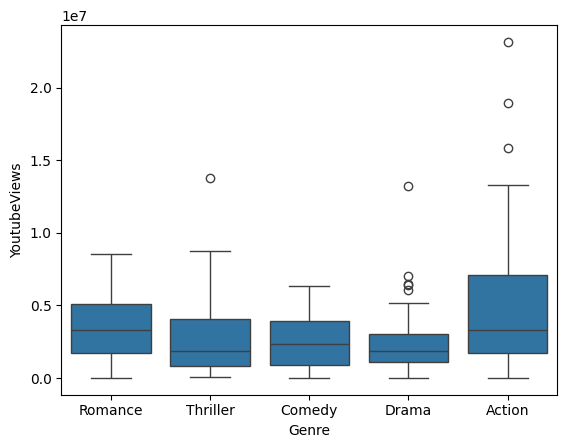

In [14]:

# 10. comparing Youtube views of genre by plotting boxplots
sns.boxplot(x='Genre', y='YoutubeViews', data=df)

<Axes: >

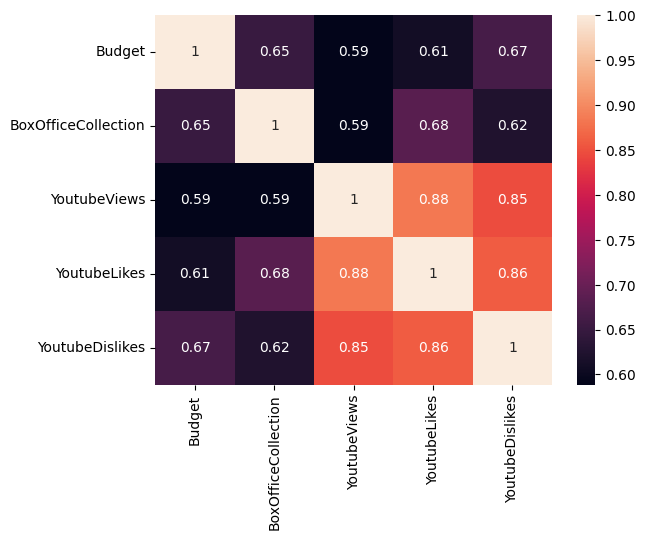

In [15]:

# 11. correlation heatmap for variables Budget, BoxOfficeCollection, YoutubeView, YoutubeLikes, YoutubeDislikes

# calculating correlation values between the variables
corr = df[['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']].corr()

# plotting a heatmap to visualize the correlation
sns.heatmap(corr, annot=True)

/tmp/ipykernel_667/1989609309.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Year', y='BoxOfficeCollection', hue='Genre', data=df, ci=None)


<Axes: xlabel='Year', ylabel='BoxOfficeCollection'>

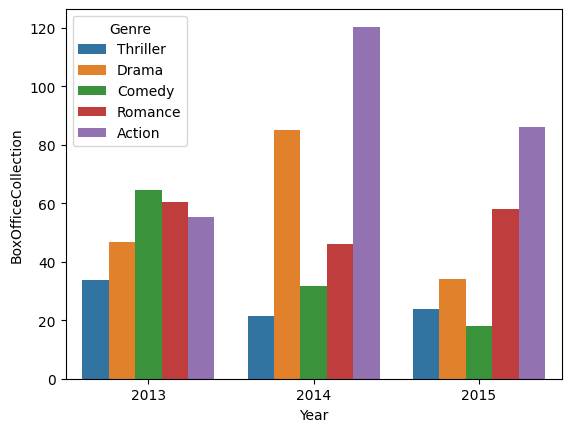

In [16]:
# 12. plotting a barplot to highlight the genre of movies and their box office collection
sns.barplot(x='Year', y='BoxOfficeCollection', hue='Genre', data=df, ci=None)

In [17]:

# 13. finding number of movies released in every year
df.Year.value_counts()

,count
Year,
2014,70
2013,67
2015,12


<Axes: xlabel='Year', ylabel='count'>

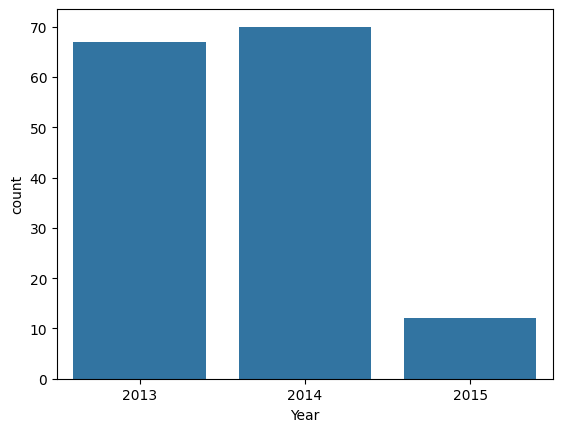

In [18]:

# 13. plotting a countplot to visualize the number of movies released every year
sns.countplot(x='Year', data=df)

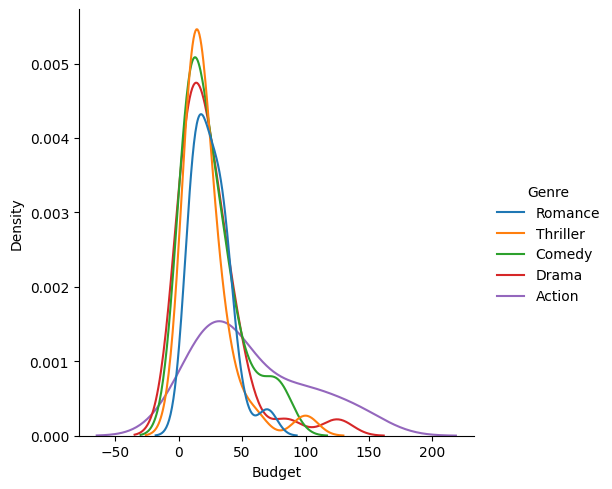

In [19]:

# 14. plotting a distplot to visualize the distribution of Budget Genre-wise
sns.displot(x='Budget', data=df, kind='kde', hue='Genre')

In [20]:

# 15. finding number of YoutubeLikes every year
df.groupby(by='Year').YoutubeLikes.sum()

,YoutubeLikes
Year,
2013,324180
2014,710142
2015,139431


In [22]:

# 15. finding number of YoutubeDislikes every year
df.groupby(by='Year').YoutubeDislikes.sum()

,YoutubeDislikes
Year,
2013,58156
2014,104682
2015,17127


<Axes: >

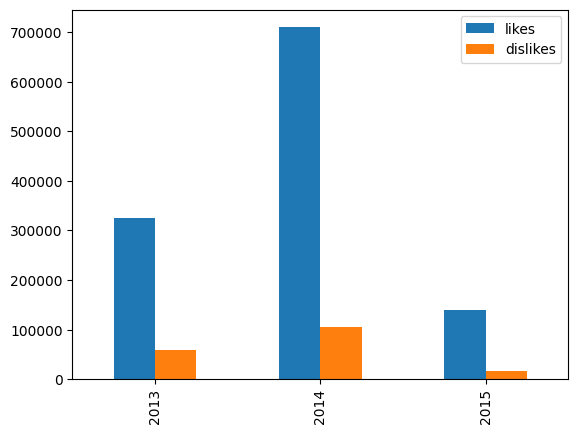

In [23]:
# listing the above results
likes = [324180, 710142, 139431]
dislikes = [58156, 104682, 17127]
year = ['2013', '2014', '2015']

# converting the results into a dataframe
compare = pd.DataFrame({'likes':likes, 'dislikes':dislikes}, index=year)

# 15. plotting the dataframe
compare.plot.bar()